# EDA: Index of Economic Freedom 2026

**Курсовой проект:** исследование взаимосвязи экономической свободы и развития финтеха.

В этом ноутбуке проводится разведочный анализ датасета **Index of Economic Freedom 2026**. 
Цель EDA — понять структуру данных, качество наблюдений, распределения показателей, различия между регионами и взаимосвязи между компонентами экономической свободы.

### Основные задачи
1. Загрузить и очистить данные.
2. Изучить структуру датасета и пропуски.
3. Рассмотреть описательную статистику показателей.
4. Проанализировать распределения ключевых индексов.
5. Сравнить регионы.
6. Исследовать корреляции между компонентами экономической свободы.
7. Подготовить признаки, которые могут быть полезны для последующего анализа связи с показателями финтеха.

> **Примечание:** исходный файл предоставлен в формате `.xlsx`, поэтому ноутбук использует Excel-файл напрямую.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# Если используется CSV, замените эту строку на:
# raw = pd.read_csv("your_file.csv", header=None)

raw = pd.read_excel("2026_indexofeconomicfreedom_data (1).xlsx", header=None)

print("Размер исходного файла:", raw.shape)
display(raw.head())


Размер исходного файла: (186, 15)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,NaN,NaN,NaN,COMPONENT SCORES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Country,Region,Overall Score,Property Rights,Judicial Efectiveness,Government Integrity,Tax Burden,Government Spending,Fiscal Health,Business Freedom,Labor Freedom,Monitary Freedom,Trade Freedom,Investment Freedom,Financial Freedom
2,Afghanistan,Asia-Pacific,NaN,3.60,0,13.50,92,90.80,98.40,33.70,44.40,84.90,NaN,NaN,NaN
3,Albania,Europe,68,57.60,59.90,41.90,89.30,74.30,88,76.60,46.20,78.60,83,60,60
4,Algeria,Middle East / North Africa,45.80,27.70,30,29.40,80.30,61.90,15.40,59.30,52.20,74.70,58.80,30,30


## 1. Подготовка и очистка данных

В исходном Excel-файле названия столбцов расположены во второй строке, а первая строка содержит объединённый заголовок `COMPONENT SCORES`. Поэтому сначала восстанавливаем корректные названия переменных.

Категориальные признаки:
- `Country` — страна;
- `Region` — регион.

Числовые признаки — общий показатель экономической свободы и 12 его компонентов.


In [2]:
headers = raw.iloc[1].tolist()
headers[0] = "Country"
headers[1] = "Region"
headers[2] = "Overall Score"

df = raw.iloc[2:].copy()
df.columns = headers
df = df.reset_index(drop=True)

score_cols = [c for c in df.columns if c not in ["Country", "Region"]]

for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Размер очищенного датасета:", df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))


Размер очищенного датасета: (184, 15)


,Country,Region,Overall Score,Property Rights,Judicial Efectiveness,Government Integrity,Tax Burden,Government Spending,Fiscal Health,Business Freedom,Labor Freedom,Monitary Freedom,Trade Freedom,Investment Freedom,Financial Freedom
0,Afghanistan,Asia-Pacific,NaN,3.60,0.00,13.50,92.00,90.80,98.40,33.70,44.40,84.90,NaN,NaN,NaN
1,Albania,Europe,68.00,57.60,59.90,41.90,89.30,74.30,88.00,76.60,46.20,78.60,83.00,60.00,60.00
2,Algeria,Middle East / North Africa,45.80,27.70,30.00,29.40,80.30,61.90,15.40,59.30,52.20,74.70,58.80,30.00,30.00
3,Angola,Sub-Saharan Africa,54.40,36.90,26.30,28.30,86.90,89.30,91.90,42.80,50.80,59.00,70.40,30.00,40.00
4,Argentina,Americas,57.40,41.20,58.20,41.20,67.80,62.30,72.20,56.80,53.50,28.90,67.40,70.00,70.00


,dtype
Country,object
Region,object
Overall Score,float64
Property Rights,float64
Judicial Efectiveness,float64
Government Integrity,float64
Tax Burden,float64
Government Spending,float64
Fiscal Health,float64
Business Freedom,float64


## 2. Структура датасета

In [3]:
print(f"Количество стран: {df['Country'].nunique()}")
print(f"Количество регионов: {df['Region'].nunique()}")
print(f"Количество числовых показателей: {len(score_cols)}")

display(pd.DataFrame({
    "Тип": ["Категориальные", "Числовые"],
    "Количество": [2, len(score_cols)]
}))

display(df.describe(include="all").T)


Количество стран: 184
Количество регионов: 5
Количество числовых показателей: 13


,Тип,Количество
0,Категориальные,2
1,Числовые,13


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,184,184,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,184,5,Sub-Saharan Africa,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Overall Score,176.00,NaN,NaN,NaN,59.95,11.70,3.10,52.48,60.00,68.00,84.40
Property Rights,184.00,NaN,NaN,NaN,52.18,26.48,0.00,32.83,49.00,72.03,99.90
Judicial Efectiveness,184.00,NaN,NaN,NaN,48.19,28.02,0.00,26.38,45.40,71.10,99.10
Government Integrity,184.00,NaN,NaN,NaN,44.71,22.39,3.60,27.10,41.75,60.02,98.00
Tax Burden,184.00,NaN,NaN,NaN,78.39,12.90,0.00,71.83,79.05,87.80,99.90
Government Spending,178.00,NaN,NaN,NaN,66.34,24.79,0.00,52.23,74.20,85.57,98.70
Fiscal Health,180.00,NaN,NaN,NaN,65.89,31.02,0.00,47.10,76.40,92.20,99.90
Business Freedom,184.00,NaN,NaN,NaN,62.18,17.35,5.00,50.52,65.40,75.45,92.30


## 3. Пропущенные значения

Пропуски особенно важны для курсового проекта, поскольку дальнейшее объединение с Global Findex может уменьшить число стран в общей выборке.

Для каждого показателя посмотрим абсолютное и относительное количество пропусков.


,missing_count,missing_share_%
Overall Score,8,4.35
Trade Freedom,7,3.80
Investment Freedom,7,3.80
Financial Freedom,7,3.80
Government Spending,6,3.26
Fiscal Health,4,2.17
Monitary Freedom,2,1.09
Country,0,0.00
Region,0,0.00
Property Rights,0,0.00


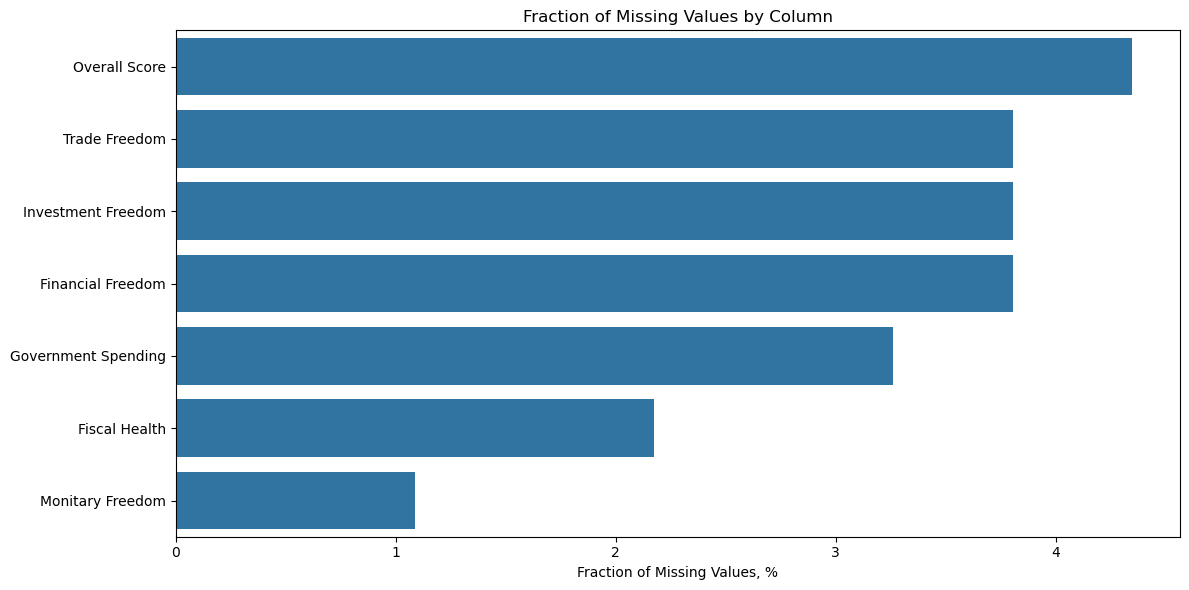

In [19]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_share_%": df.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

display(missing)

plt.figure(figsize=(12, 6))
missing_nonzero = missing[missing["missing_count"] > 0]
if len(missing_nonzero) > 0:
    sns.barplot(
        x=missing_nonzero["missing_share_%"],
        y=missing_nonzero.index
    )
    plt.xlabel("Fraction of Missing Values, %")
    plt.ylabel("")
    plt.title("Fraction of Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values.")


## 4. Распределение общего показателя экономической свободы

`Overall Score` — основной агрегированный показатель экономической свободы. 

На графиках ниже рассматриваются:
- распределение значений;
- среднее и медианное значение;
- возможная асимметрия;
- наличие выбросов.


Average: 59.94545454545455
Median: 60.0
Standard Deviation: 11.699566869549697
Minimum: 3.1
Maximum: 84.4


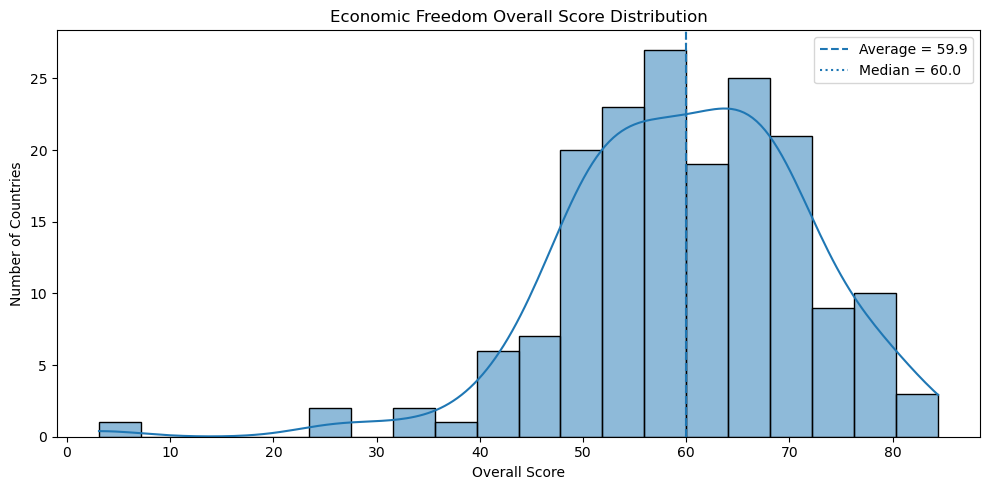

In [18]:
overall = df["Overall Score"].dropna()

print("Average:", overall.mean())
print("Median:", overall.median())
print("Standard Deviation:", overall.std())
print("Minimum:", overall.min())
print("Maximum:", overall.max())

plt.figure(figsize=(10, 5))
sns.histplot(overall, bins=20, kde=True)
plt.axvline(overall.mean(), linestyle="--", label=f"Average = {overall.mean():.1f}")
plt.axvline(overall.median(), linestyle=":", label=f"Median = {overall.median():.1f}")
plt.xlabel("Overall Score")
plt.ylabel("Number of Countries")
plt.title("Economic Freedom Overall Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()


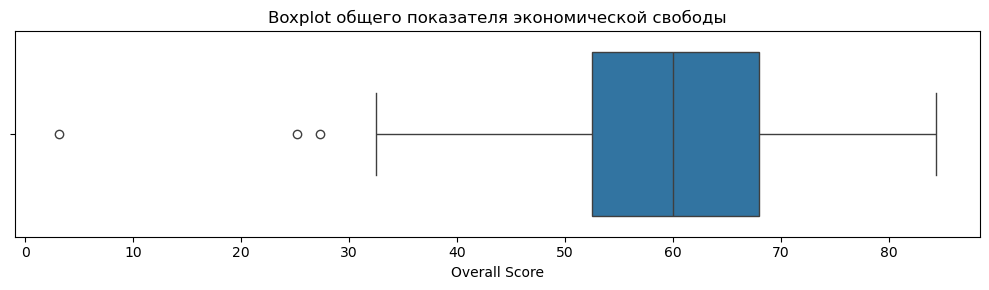

In [6]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=overall)
plt.xlabel("Overall Score")
plt.title("Boxplot общего показателя экономической свободы")
plt.tight_layout()
plt.show()


## 5. Рейтинг стран по уровню экономической свободы

Ранжирование позволяет быстро увидеть страны с наиболее высокими и низкими значениями `Overall Score`.


In [7]:
ranking = (
    df[["Country", "Region", "Overall Score"]]
    .dropna(subset=["Overall Score"])
    .sort_values("Overall Score", ascending=False)
)

display(ranking.head(10))
display(ranking.tail(10).sort_values("Overall Score"))


,Country,Region,Overall Score
147,Singapore,Asia-Pacific,84.40
158,Switzerland,Europe,83.70
78,Ireland,Europe,83.30
6,Australia,Asia-Pacific,80.10
160,Taiwan,Asia-Pacific,79.80
100,Luxembourg,Europe,79.70
45,Denmark,Europe,79.00
124,Norway,Europe,78.80
54,Estonia,Europe,78.70
118,Netherlands,Europe,78.50


,Country,Region,Overall Score
87,North Korea,Asia-Pacific,3.10
42,Cuba,Americas,25.20
179,Venezuela,Americas,27.30
155,Sudan,Sub-Saharan Africa,32.50
183,Zimbabwe,Sub-Saharan Africa,35.20
53,Eritrea,Sub-Saharan Africa,39.60
26,Burundi,Sub-Saharan Africa,40.20
76,Iran,Middle East / North Africa,41.80
18,Bolivia,Americas,42.40
94,Lebanon,Middle East / North Africa,43.10


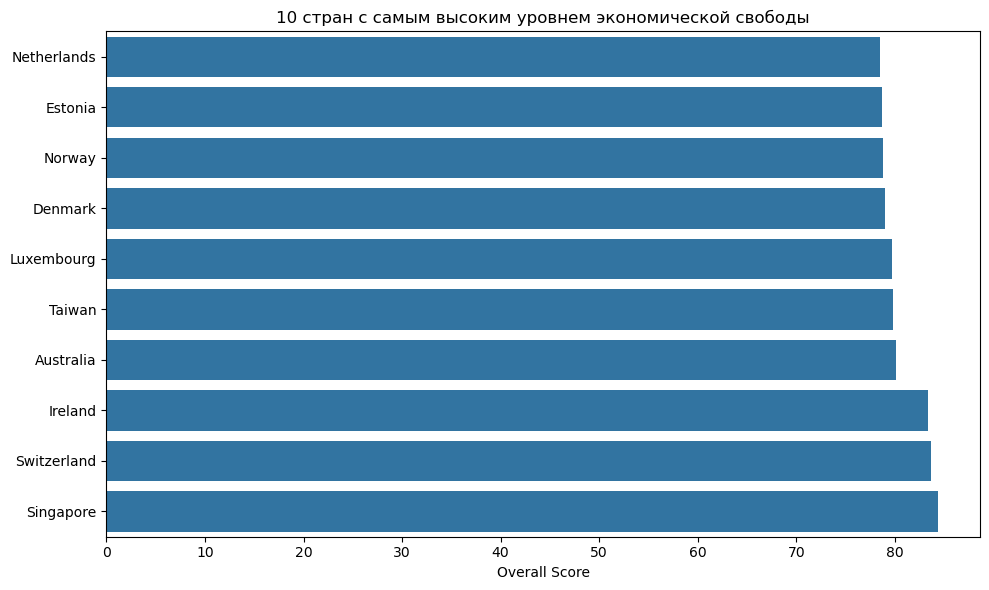

In [8]:
top10 = ranking.head(10).sort_values("Overall Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x="Overall Score", y="Country")
plt.xlabel("Overall Score")
plt.ylabel("")
plt.title("10 стран с самым высоким уровнем экономической свободы")
plt.tight_layout()
plt.show()


## 6. Сравнение регионов

Региональный анализ нужен, чтобы понять, насколько сильно различается экономическая свобода в разных частях мира.

Для каждого региона рассчитываются:
- среднее значение;
- медиана;
- стандартное отклонение;
- количество стран.


In [9]:
region_stats = (
    df.groupby("Region")["Overall Score"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(region_stats)


,count,mean,median,std,min,max
Region,,,,,,
Europe,44,68.93,68.70,7.75,49.10,83.70
Americas,32,59.66,61.20,11.62,25.20,75.60
Asia-Pacific,39,58.65,58.90,13.55,3.10,84.40
Middle East / North Africa,14,58.59,60.85,10.67,41.80,71.90
Sub-Saharan Africa,47,53.21,53.10,8.02,32.50,73.00


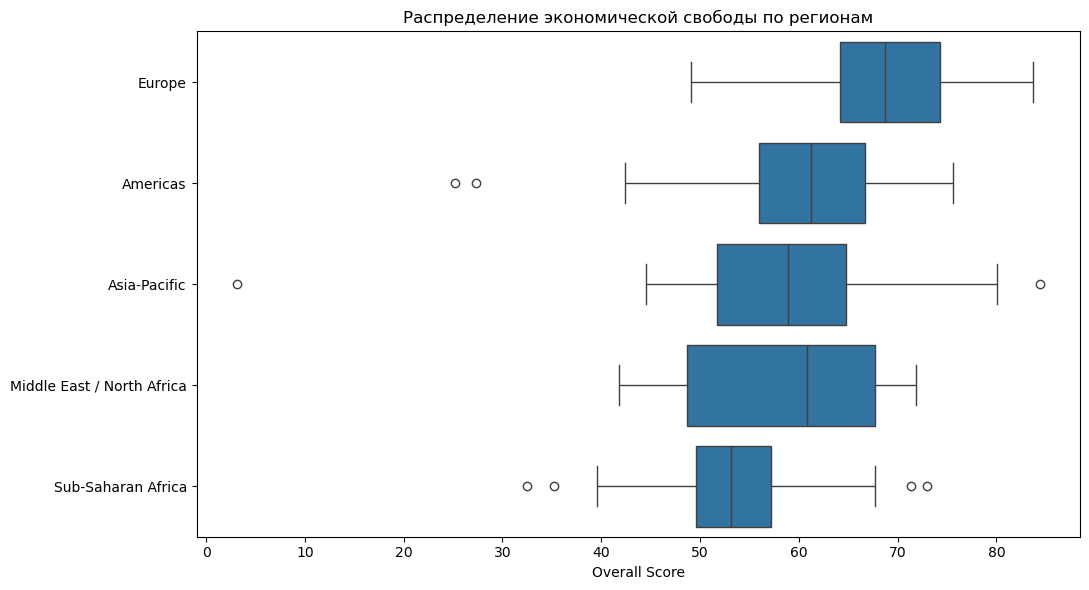

In [10]:
plt.figure(figsize=(11, 6))
order = region_stats.index
sns.boxplot(data=df, x="Overall Score", y="Region", order=order)
plt.xlabel("Overall Score")
plt.ylabel("")
plt.title("Распределение экономической свободы по регионам")
plt.tight_layout()
plt.show()


## 7. Анализ компонентов экономической свободы

`Overall Score` состоит из набора отдельных компонентов, отражающих разные аспекты экономической среды.

В частности, датасет содержит показатели:
- Property Rights;
- Judicial Efectiveness;
- Government Integrity;
- Tax Burden;
- Government Spending;
- Fiscal Health;
- Business Freedom;
- Labor Freedom;
- Monitary Freedom;
- Trade Freedom;
- Investment Freedom;
- Financial Freedom.

Посмотрим средние значения компонентов и сравним их между собой.


,mean_score
Tax Burden,78.39
Trade Freedom,70.18
Monitary Freedom,69.96
Government Spending,66.34
Fiscal Health,65.89
Business Freedom,62.18
Overall Score,59.95
Labor Freedom,55.13
Investment Freedom,53.45
Property Rights,52.18


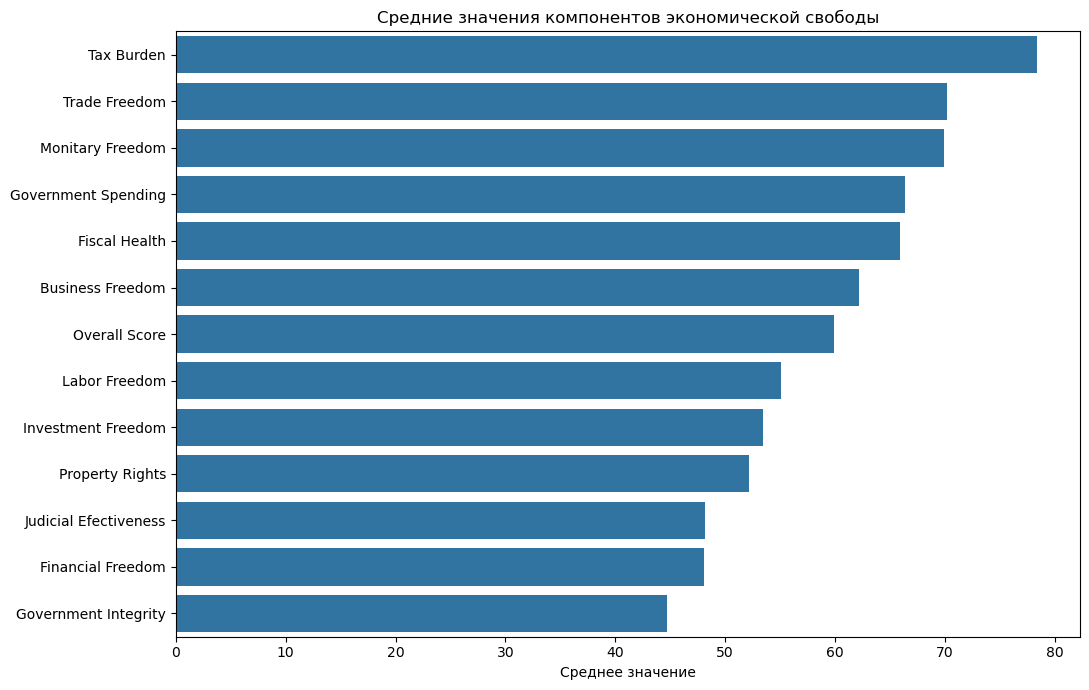

In [11]:
component_means = df[score_cols].mean().sort_values(ascending=False)

display(component_means.to_frame("mean_score"))

plt.figure(figsize=(11, 7))
sns.barplot(x=component_means.values, y=component_means.index)
plt.xlabel("Среднее значение")
plt.ylabel("")
plt.title("Средние значения компонентов экономической свободы")
plt.tight_layout()
plt.show()


## 8. Корреляционный анализ

Корреляции позволяют определить, какие компоненты экономической свободы наиболее тесно связаны с `Overall Score`.

Важно: корреляция показывает статистическую связь, но **не доказывает причинность**.


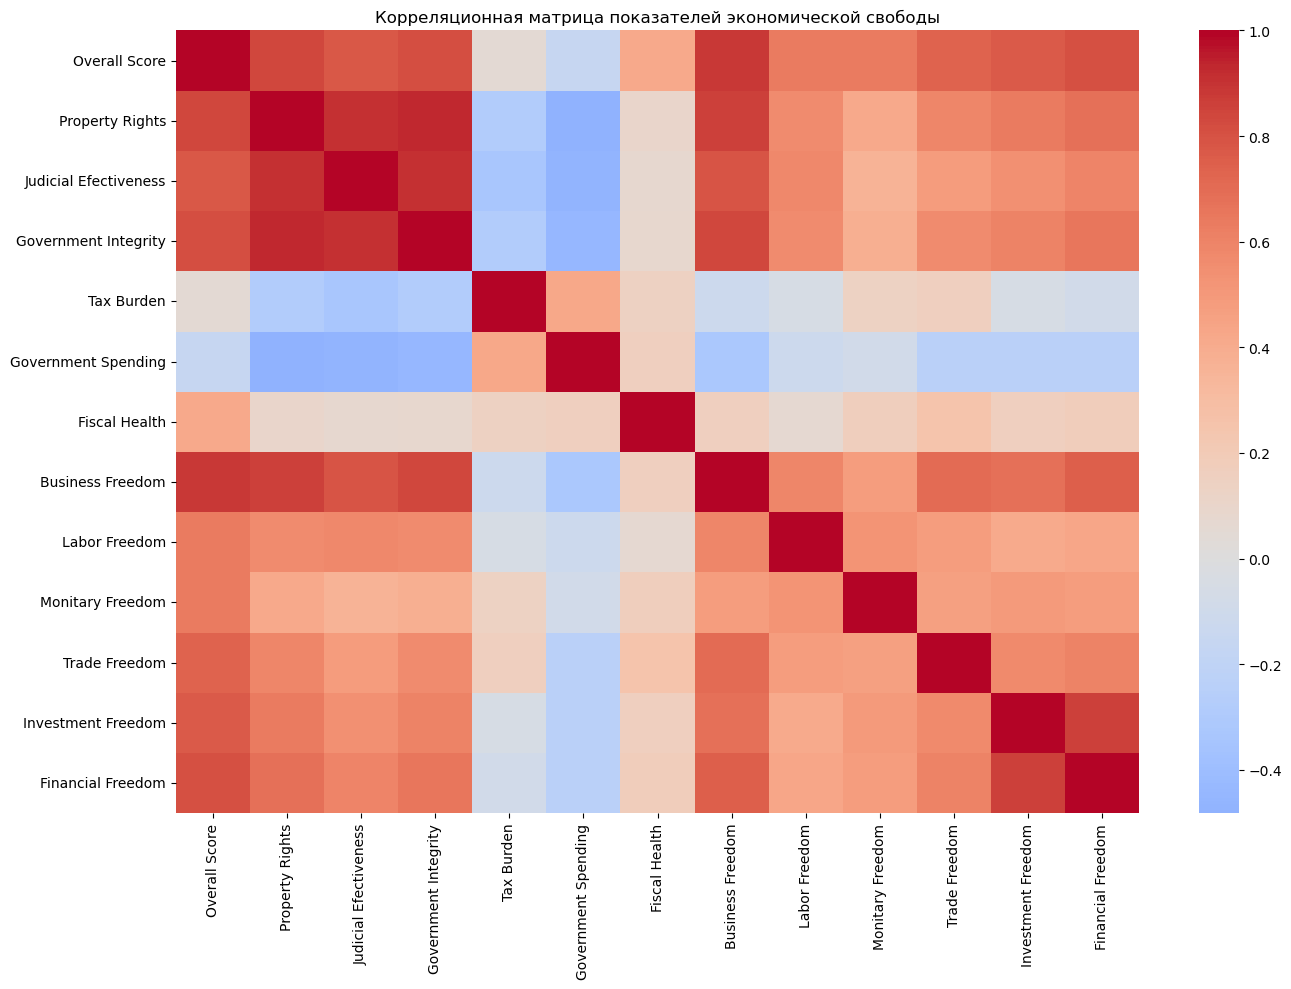

In [12]:
corr = df[score_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Корреляционная матрица показателей экономической свободы")
plt.tight_layout()
plt.show()


,correlation_with_overall
Business Freedom,0.88
Property Rights,0.83
Government Integrity,0.82
Financial Freedom,0.81
Judicial Efectiveness,0.78
Investment Freedom,0.77
Trade Freedom,0.74
Labor Freedom,0.64
Monitary Freedom,0.63
Fiscal Health,0.42


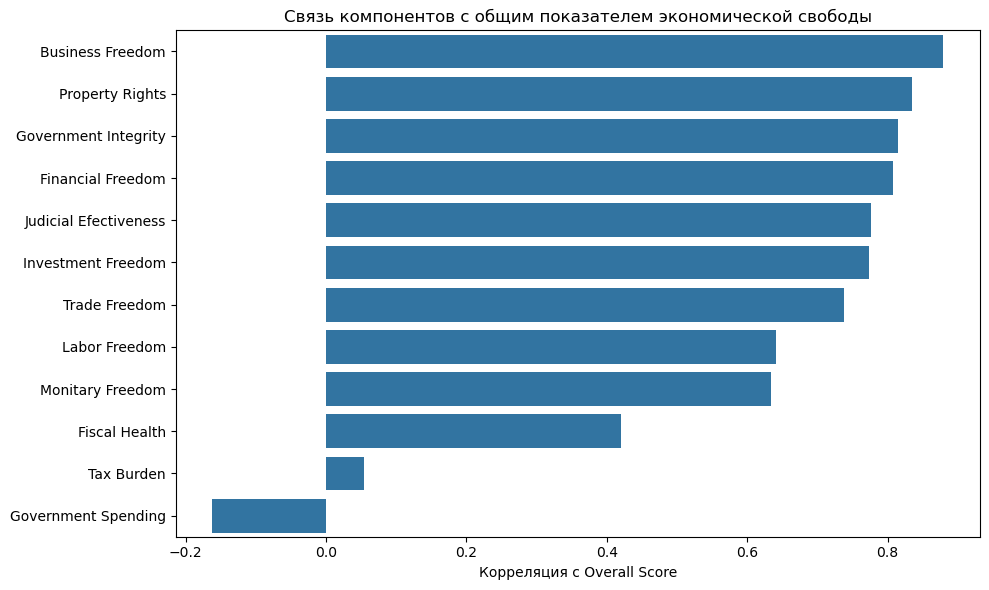

In [13]:
overall_corr = (
    df[score_cols]
    .corr()["Overall Score"]
    .drop("Overall Score")
    .sort_values(ascending=False)
)

display(overall_corr.to_frame("correlation_with_overall"))

plt.figure(figsize=(10, 6))
sns.barplot(x=overall_corr.values, y=overall_corr.index)
plt.xlabel("Корреляция с Overall Score")
plt.ylabel("")
plt.title("Связь компонентов с общим показателем экономической свободы")
plt.tight_layout()
plt.show()


## 9. Связь ключевых компонентов с Overall Score

В качестве примера отдельно рассмотрим `Financial Freedom`, поскольку этот показатель особенно интересен для курсового проекта о финтехе.

`Financial Freedom` характеризует степень свободы и независимости финансового сектора от государственного контроля и вмешательства.

Для EDA полезно проверить, насколько этот компонент связан с общим уровнем экономической свободы.


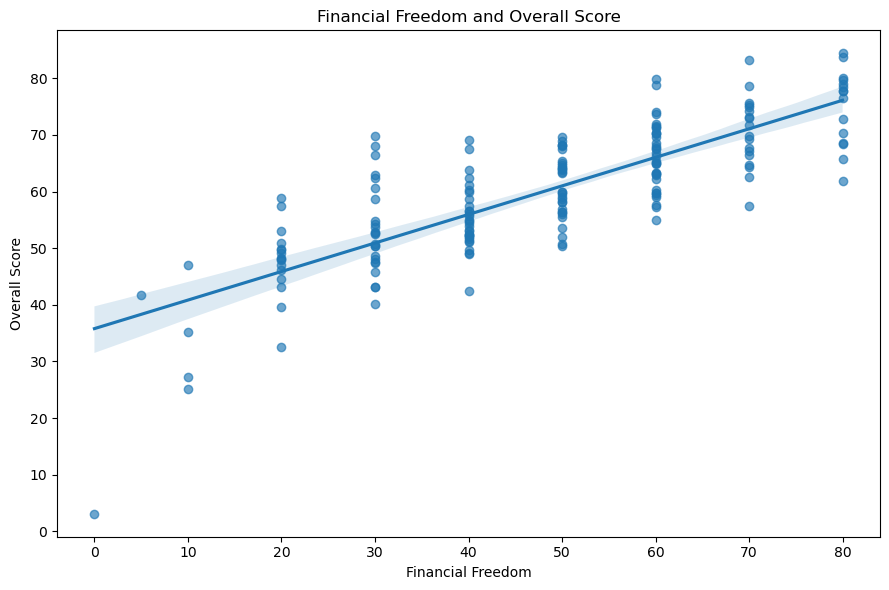

Корреляция: 0.8074418423088408


In [17]:
plot_df = df[["Financial Freedom", "Overall Score"]].dropna()

plt.figure(figsize=(9, 6))
sns.regplot(
    data=plot_df,
    x="Financial Freedom",
    y="Overall Score",
    scatter_kws={"alpha": 0.65}
)
plt.xlabel("Financial Freedom")
plt.ylabel("Overall Score")
plt.title("Financial Freedom and Overall Score")
plt.tight_layout()
plt.show()

print("Корреляция:", plot_df["Financial Freedom"].corr(plot_df["Overall Score"]))


## 10. Выбросы и необычные наблюдения

Для каждого числового показателя можно использовать межквартильный размах (IQR) для поиска потенциальных выбросов.

Такие наблюдения не следует автоматически удалять: страна с необычно высоким или низким значением может быть содержательно важна для исследования.


In [15]:
outlier_summary = []

for col in score_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((s < lower) | (s > upper)).sum()
    outlier_summary.append([col, n_outliers, n_outliers / len(s) * 100])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=["feature", "outlier_count", "outlier_share_%"]
).sort_values("outlier_count", ascending=False)

display(outlier_summary)


,feature,outlier_count,outlier_share_%
9,Monitary Freedom,23,12.64
8,Labor Freedom,9,4.89
5,Government Spending,7,3.93
0,Overall Score,3,1.70
4,Tax Burden,3,1.63
10,Trade Freedom,2,1.13
7,Business Freedom,1,0.54
1,Property Rights,0,0.00
2,Judicial Efectiveness,0,0.00
3,Government Integrity,0,0.00


## 11. Подготовка данных для объединения с Global Findex

В следующем этапе курсового проекта этот датасет можно объединить с **Global Findex 2024** по стране.

Для объединения желательно:
1. привести названия стран к единому формату;
2. проверить дубликаты;
3. определить, какие страны присутствуют в обоих источниках;
4. сохранить только те признаки, которые действительно нужны для исследовательского вопроса;
5. отдельно контролировать пропуски после merge.

### Потенциально важные признаки

**Основной показатель экономической свободы**
- `Overall Score`

**Институциональная среда**
- `Property Rights`
- `Judicial Efectiveness`
- `Government Integrity`

**Регуляторная и предпринимательская среда**
- `Business Freedom`
- `Labor Freedom`

**Финансовая среда**
- `Financial Freedom`
- `Investment Freedom`

**Международная экономическая среда**
- `Trade Freedom`

Эти признаки можно использовать как объясняющие переменные при изучении связи экономической свободы с показателями использования финансовых технологий.


In [16]:
# Проверка дубликатов
print("Дубликаты стран:", df["Country"].duplicated().sum())

# Итоговый набор данных после EDA
eda_ready = df.copy()

display(eda_ready.head())
display(eda_ready.shape)


Дубликаты стран: 0


,Country,Region,Overall Score,Property Rights,Judicial Efectiveness,Government Integrity,Tax Burden,Government Spending,Fiscal Health,Business Freedom,Labor Freedom,Monitary Freedom,Trade Freedom,Investment Freedom,Financial Freedom
0,Afghanistan,Asia-Pacific,NaN,3.60,0.00,13.50,92.00,90.80,98.40,33.70,44.40,84.90,NaN,NaN,NaN
1,Albania,Europe,68.00,57.60,59.90,41.90,89.30,74.30,88.00,76.60,46.20,78.60,83.00,60.00,60.00
2,Algeria,Middle East / North Africa,45.80,27.70,30.00,29.40,80.30,61.90,15.40,59.30,52.20,74.70,58.80,30.00,30.00
3,Angola,Sub-Saharan Africa,54.40,36.90,26.30,28.30,86.90,89.30,91.90,42.80,50.80,59.00,70.40,30.00,40.00
4,Argentina,Americas,57.40,41.20,58.20,41.20,67.80,62.30,72.20,56.80,53.50,28.90,67.40,70.00,70.00


(184, 15)

# Итоговые выводы EDA

После выполнения ноутбука в текстовом отчёте курсовой работы стоит зафиксировать:

1. **Структуру выборки:** сколько стран и регионов представлено.
2. **Качество данных:** какие признаки содержат пропуски и насколько они существенны.
3. **Распределение Overall Score:** среднее, медиана, разброс и наличие потенциальных выбросов.
4. **Региональные различия:** какие регионы имеют более высокий/низкий средний уровень экономической свободы.
5. **Наиболее сильные взаимосвязи:** какие компоненты наиболее тесно коррелируют с `Overall Score`.
6. **Financial Freedom:** отдельно отметить его связь с общим индексом, поскольку этот показатель непосредственно связан с финансовой системой.
7. **Следующий этап:** объединить данные с Global Findex и проверить, существует ли статистическая связь между уровнем экономической свободы и показателями развития/использования финтеха.

### Важное ограничение

Корреляционный анализ на уровне стран позволяет выявлять **ассоциации**, но сам по себе не позволяет сделать вывод о причинно-следственной связи. Для основной части курсовой необходимо дополнительно использовать статистические тесты и/или регрессионный анализ с контролем потенциальных факторов.
